In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, precision_recall_fscore_support
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [5]:
emotion_df = pd.read_csv(r"C:\Users\LOQ\OneDrive\Desktop\NLP\data\emotion_augmented_backtranslation.csv")
violence_df = pd.read_csv(r"C:\Users\LOQ\OneDrive\Desktop\NLP\data\violence_augmented_backtranslation.csv")
hate_df = pd.read_csv(r"C:\Users\LOQ\OneDrive\Desktop\NLP\data\hate_augmented_backtranslation.csv")

In [8]:
emotion_df.shape, violence_df.shape, hate_df.shape

((431781, 2), (86648, 2), (37190, 2))

In [9]:
emotion_df['label'].value_counts() , violence_df['label'].value_counts() , hate_df['label'].value_counts()

(label
 1    141067
 0    121187
 3     57317
 4     47712
 2     34554
 5     29944
 Name: count, dtype: int64,
 label
 4    32648
 1    18000
 3    12000
 0    12000
 2    12000
 Name: count, dtype: int64,
 label
 1    19190
 2     9000
 0     9000
 Name: count, dtype: int64)

# CLASSIFICATION USING AUGMENTED DATASETS

In [10]:
# ============================================================================
# TF-IDF VECTORIZATION
# ============================================================================

print("\nCreating TF-IDF features...")
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))

# Fit on all text data
all_text = pd.concat([emotion_df['text'], violence_df['text'], hate_df['text']])
tfidf.fit(all_text)

# Transform datasets
X_emotion = tfidf.transform(emotion_df['text'])
y_emotion = emotion_df['label'].values

X_violence = tfidf.transform(violence_df['text'])
y_violence = violence_df['label'].values

X_hate = tfidf.transform(hate_df['text'])
y_hate = hate_df['label'].values



Creating TF-IDF features...


In [11]:
# Split data
print("Splitting data into train/test sets (80/20)...")
X_emotion_train, X_emotion_test, y_emotion_train, y_emotion_test = train_test_split(
    X_emotion, y_emotion, test_size=0.2, random_state=42, stratify=y_emotion
)

X_violence_train, X_violence_test, y_violence_train, y_violence_test = train_test_split(
    X_violence, y_violence, test_size=0.2, random_state=42, stratify=y_violence
)

X_hate_train, X_hate_test, y_hate_train, y_hate_test = train_test_split(
    X_hate, y_hate, test_size=0.2, random_state=42, stratify=y_hate
)

Splitting data into train/test sets (80/20)...


In [17]:
# Prepare labels
emotion_labels_text = ['Sadness', 'Joy', 'Love', 'Anger', 'Fear', 'Surprise']
violence_labels_text = ['Harmful Traditional Practice', 'Physical Violence', 'Economic Violence', 'Emotional Violence', 'Sexual Violence']
hate_labels_text = ['Hate Speech', 'Offensive Speech', 'Neither']

In [12]:
scores = []

In [13]:
def evaluate_model(model_name, emotion_pred, violence_pred, hate_pred):
    # Accuracy
    emotion_acc = accuracy_score(y_emotion_test, emotion_pred)
    violence_acc = accuracy_score(y_violence_test, violence_pred)
    hate_acc = accuracy_score(y_hate_test, hate_pred)
    overall_acc = (emotion_acc + violence_acc + hate_acc) / 3
    scores.append(overall_acc)

    # Precision
    emotion_prec = precision_score(y_emotion_test, emotion_pred, average='macro')
    violence_prec = precision_score(y_violence_test, violence_pred, average='macro')
    hate_prec = precision_score(y_hate_test, hate_pred, average='macro')
    overall_prec = (emotion_prec + violence_prec + hate_prec) / 3

    # Recall
    emotion_rec = recall_score(y_emotion_test, emotion_pred, average='macro')
    violence_rec = recall_score(y_violence_test, violence_pred, average='macro')
    hate_rec = recall_score(y_hate_test, hate_pred, average='macro')
    overall_rec = (emotion_rec + violence_rec + hate_rec) / 3

    # F1-score
    emotion_f1 = f1_score(y_emotion_test, emotion_pred, average='macro')
    violence_f1 = f1_score(y_violence_test, violence_pred, average='macro')
    hate_f1 = f1_score(y_hate_test, hate_pred, average='macro')
    overall_f1 = (emotion_f1 + violence_f1 + hate_f1) / 3
    
    # Print evaluation table
    print("\n" + "-"*75)
    print(f"{'CLASS':<15}{'ACCURACY':<15}{'PRECISION':<15}{'RECALL':<15}{'F1-SCORE':<15}")
    print("-"*75)

    print(f"{'Emotion':<15}{emotion_acc:<15.4f}{emotion_prec:<15.4f}{emotion_rec:<15.4f}{emotion_f1:<15.4f}")
    print(f"{'Violence':<15}{violence_acc:<15.4f}{violence_prec:<15.4f}{violence_rec:<15.4f}{violence_f1:<15.4f}")
    print(f"{'Hate Speech':<15}{hate_acc:<15.4f}{hate_prec:<15.4f}{hate_rec:<15.4f}{hate_f1:<15.4f}")

    print("-"*75)
    print(f"{'Overall Avg':<15}{overall_acc:<15.4f}{overall_prec:<15.4f}{overall_rec:<15.4f}{overall_f1:<15.4f}")
    print("-"*75)


In [42]:
def plot_confusion_matrices_subplot(emotion_pred, violence_pred, hate_pred, model_name):
    
    fig, axes = plt.subplots(
        1, 3,
        figsize=(18, 6),          # wider figure
        constrained_layout=True  # better than tight_layout
    )
    
    # ---------- Emotion ----------
    cm_emotion = confusion_matrix(y_emotion_test, emotion_pred, normalize='true')
    sns.heatmap(
        cm_emotion,
        annot=True,
        fmt='.2f',
        cmap='Blues',
        xticklabels=emotion_labels_text,
        yticklabels=emotion_labels_text,
        ax=axes[0],
        #cbar_kws={'shrink': 0.75}
    )
    axes[0].set_title(f'{model_name}\nEmotion Classification', fontweight='bold')
    
    # ---------- Violence ----------
    cm_violence = confusion_matrix(y_violence_test, violence_pred, normalize='true')
    sns.heatmap(
        cm_violence,
        annot=True,
        fmt='.2f',
        cmap='Greens',
        xticklabels=violence_labels_text,
        yticklabels=violence_labels_text,
        ax=axes[1],
        #cbar_kws={'shrink': 0.75}
    )
    axes[1].set_title(f'{model_name}\nViolence Classification', fontweight='bold')
    
    # ---------- Hate Speech ----------
    cm_hate = confusion_matrix(y_hate_test, hate_pred, normalize='true')
    sns.heatmap(
        cm_hate,
        annot=True,
        fmt='.2f',
        cmap='Oranges',
        xticklabels=hate_labels_text,
        yticklabels=hate_labels_text,
        ax=axes[2],
        #cbar_kws={'shrink': 0.75}
    )
    axes[2].set_title(f'{model_name}\nHate Speech Classification', fontweight='bold')
    
    # ---------- Fix label overwriting ----------
    for ax in axes:
        ax.set_xticklabels(
            ax.get_xticklabels(),
            rotation=90,
            ha='center',
            va='top',
            fontsize=9
        )
        ax.set_yticklabels(
            ax.get_yticklabels(),
            rotation=0,
            ha='right',
            va='center',
            fontsize=9
        )
        ax.tick_params(axis='x', pad=6)  # space from axis
    
    plt.show()


In [15]:
# ============================================================================
# 1. RANDOM FOREST
# ============================================================================
print("\n" + "="*80)
print("TRAINING RANDOM FOREST CLASSIFIER")
print("="*80)

rf_emotion = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_violence = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_hate = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

print("Training models...")
rf_emotion.fit(X_emotion_train, y_emotion_train)
rf_violence.fit(X_violence_train, y_violence_train)
rf_hate.fit(X_hate_train, y_hate_train)

rf_emotion_pred = rf_emotion.predict(X_emotion_test)
rf_violence_pred = rf_violence.predict(X_violence_test)
rf_hate_pred = rf_hate.predict(X_hate_test)

evaluate_model('Random Forest', rf_emotion_pred, rf_violence_pred, rf_hate_pred)


TRAINING RANDOM FOREST CLASSIFIER
Training models...

---------------------------------------------------------------------------
CLASS          ACCURACY       PRECISION      RECALL         F1-SCORE       
---------------------------------------------------------------------------
Emotion        0.8466         0.8101         0.8152         0.8125         
Violence       0.9992         0.9994         0.9995         0.9994         
Hate Speech    0.9204         0.9155         0.9194         0.9174         
---------------------------------------------------------------------------
Overall Avg    0.9221         0.9083         0.9114         0.9098         
---------------------------------------------------------------------------


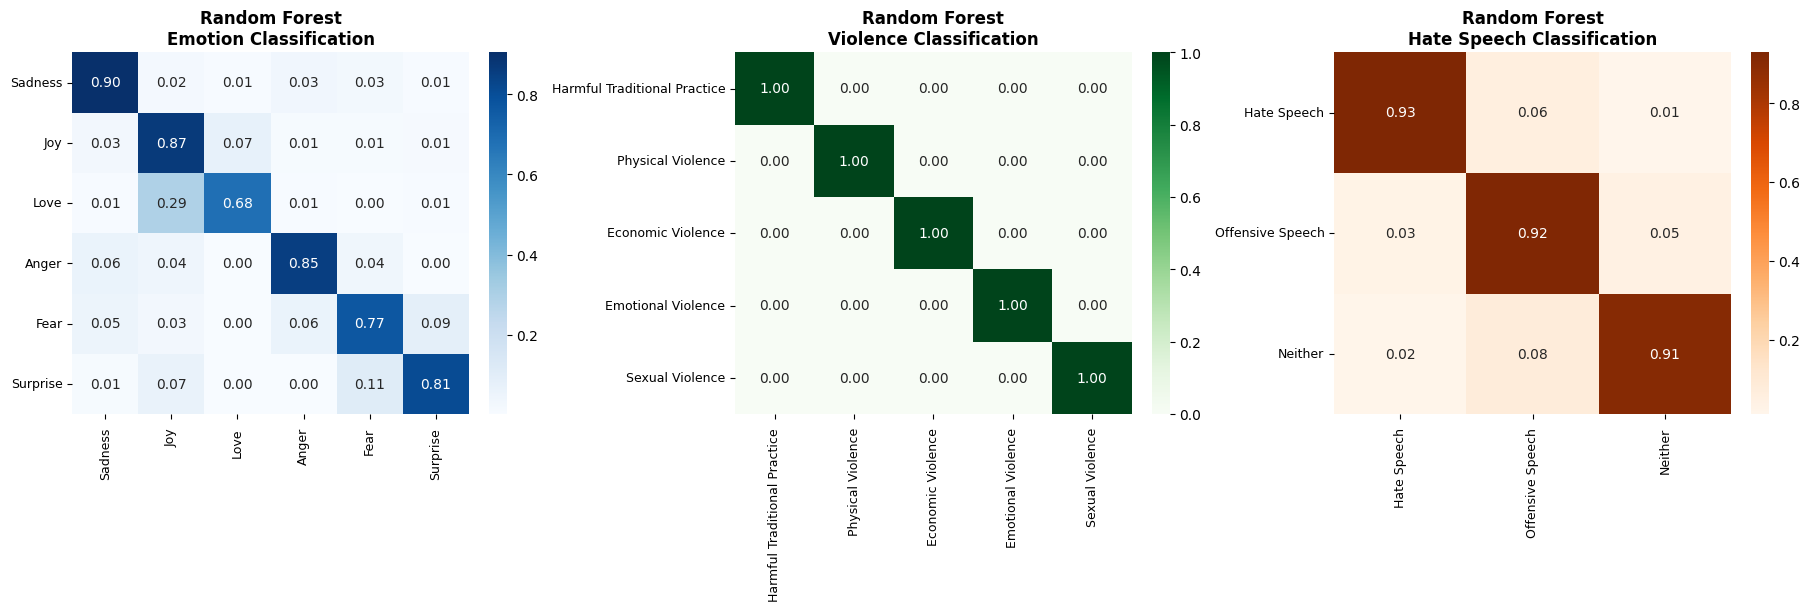

In [43]:
plot_confusion_matrices_subplot(rf_emotion_pred, rf_violence_pred, rf_hate_pred, 'Random Forest')

In [44]:
# ============================================================================
# 2. XGBOOST
# ============================================================================
print("\n" + "="*80)
print("TRAINING XGBOOST CLASSIFIER")
print("="*80)

xgb_emotion = XGBClassifier(n_estimators=100, random_state=42, n_jobs=-1, eval_metric='mlogloss')
xgb_violence = XGBClassifier(n_estimators=100, random_state=42, n_jobs=-1, eval_metric='mlogloss')
xgb_hate = XGBClassifier(n_estimators=100, random_state=42, n_jobs=-1, eval_metric='mlogloss')

print("Training models...")
xgb_emotion.fit(X_emotion_train, y_emotion_train)
xgb_violence.fit(X_violence_train, y_violence_train)
xgb_hate.fit(X_hate_train, y_hate_train)

xgb_emotion_pred = xgb_emotion.predict(X_emotion_test)
xgb_violence_pred = xgb_violence.predict(X_violence_test)
xgb_hate_pred = xgb_hate.predict(X_hate_test)

evaluate_model('XGBoost', xgb_emotion_pred, xgb_violence_pred, xgb_hate_pred)


TRAINING XGBOOST CLASSIFIER
Training models...

---------------------------------------------------------------------------
CLASS          ACCURACY       PRECISION      RECALL         F1-SCORE       
---------------------------------------------------------------------------
Emotion        0.8857         0.8593         0.8823         0.8683         
Violence       0.9992         0.9992         0.9995         0.9993         
Hate Speech    0.8603         0.8422         0.8540         0.8440         
---------------------------------------------------------------------------
Overall Avg    0.9151         0.9002         0.9119         0.9039         
---------------------------------------------------------------------------


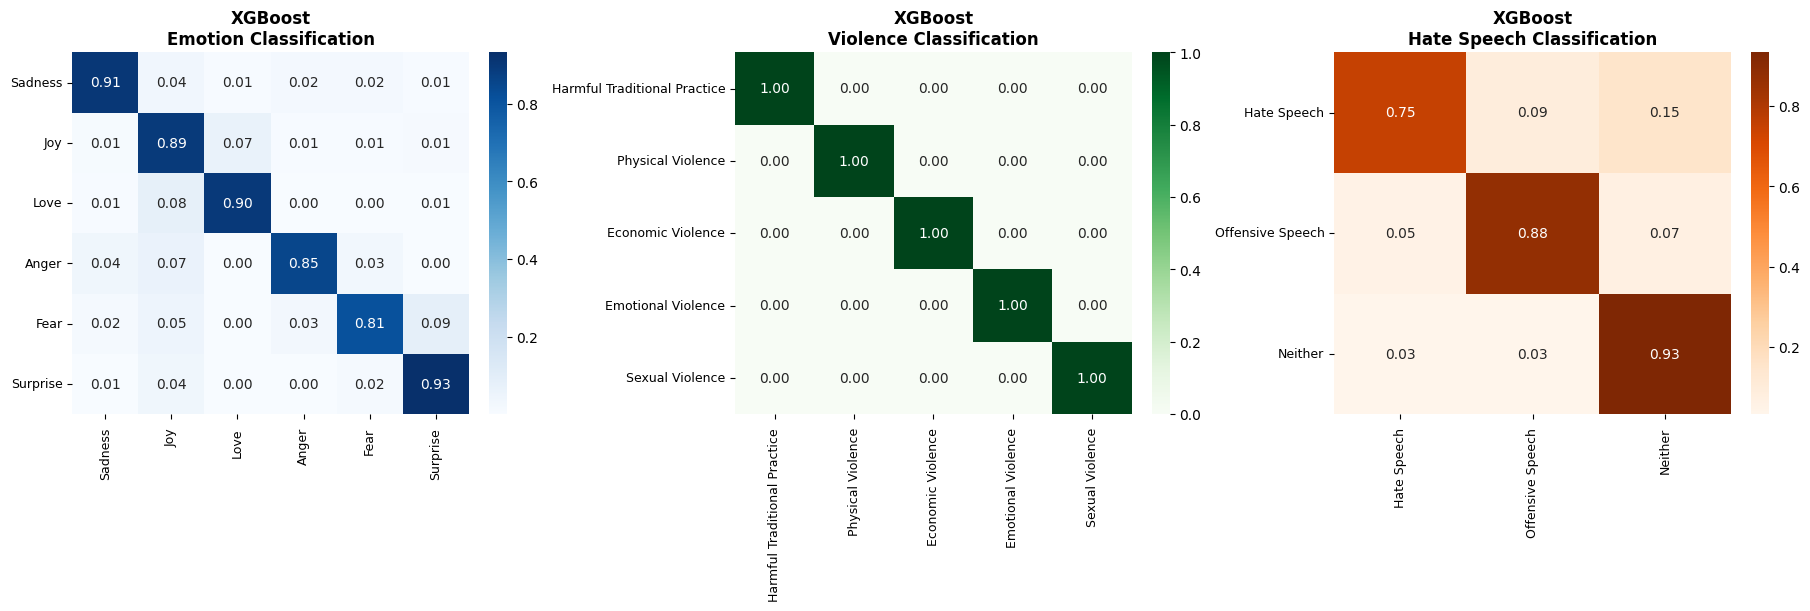

In [45]:
plot_confusion_matrices_subplot(xgb_emotion_pred, xgb_violence_pred, xgb_hate_pred, 'XGBoost')

In [46]:
# ============================================================================
# 3. SVM
# ============================================================================
print("\n" + "="*80)
print("TRAINING SVM CLASSIFIER")
print("="*80)

svm_emotion = SVC(kernel='linear', random_state=42)
svm_violence = SVC(kernel='linear', random_state=42)
svm_hate = SVC(kernel='linear', random_state=42)

print("Training models...")
svm_emotion.fit(X_emotion_train, y_emotion_train)
svm_violence.fit(X_violence_train, y_violence_train)
svm_hate.fit(X_hate_train, y_hate_train)

svm_emotion_pred = svm_emotion.predict(X_emotion_test)
svm_violence_pred = svm_violence.predict(X_violence_test)
svm_hate_pred = svm_hate.predict(X_hate_test)

evaluate_model('SVM', svm_emotion_pred, svm_violence_pred, svm_hate_pred)


TRAINING SVM CLASSIFIER
Training models...

---------------------------------------------------------------------------
CLASS          ACCURACY       PRECISION      RECALL         F1-SCORE       
---------------------------------------------------------------------------
Emotion        0.8874         0.8671         0.8596         0.8620         
Violence       0.9991         0.9992         0.9994         0.9993         
Hate Speech    0.8537         0.8339         0.8466         0.8393         
---------------------------------------------------------------------------
Overall Avg    0.9134         0.9001         0.9019         0.9002         
---------------------------------------------------------------------------


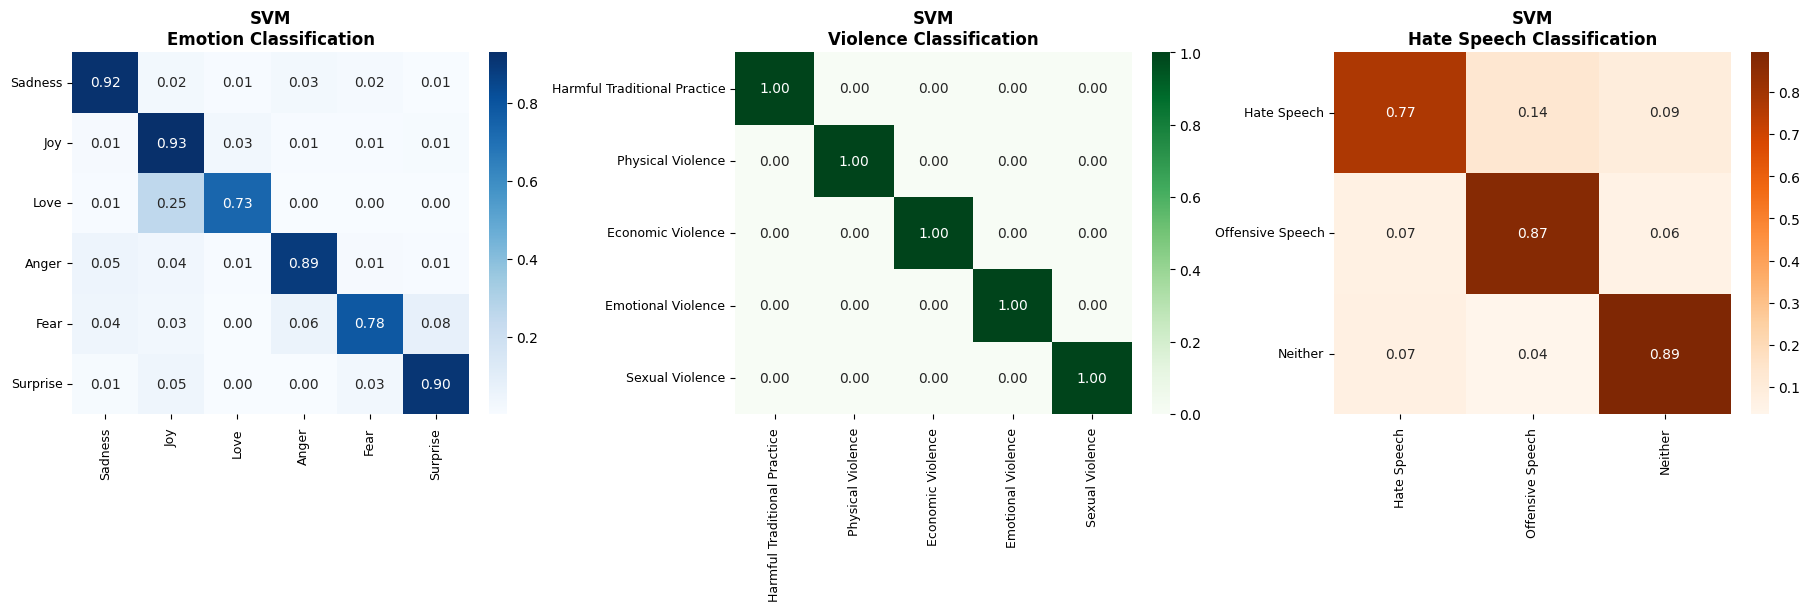

In [47]:
plot_confusion_matrices_subplot(svm_emotion_pred, svm_violence_pred, svm_hate_pred, 'SVM')

In [48]:
# ============================================================================
# 4. Complement Naive Bayes
# ============================================================================
print("\n" + "="*80)
print("TRAINING CNB CLASSIFIER")
print("="*80)

cnb_emotion = ComplementNB(alpha=0.1)
cnb_violence = ComplementNB(alpha=0.1)
cnb_hate = ComplementNB(alpha=0.1)

print("Training models...")
cnb_emotion.fit(X_emotion_train, y_emotion_train)
cnb_violence.fit(X_violence_train, y_violence_train)
cnb_hate.fit(X_hate_train, y_hate_train)

cnb_emotion_pred = cnb_emotion.predict(X_emotion_test)
cnb_violence_pred = cnb_violence.predict(X_violence_test)
cnb_hate_pred = cnb_hate.predict(X_hate_test)

evaluate_model('Complement Naive Bayes', cnb_emotion_pred, cnb_violence_pred, cnb_hate_pred)


TRAINING CNB CLASSIFIER
Training models...

---------------------------------------------------------------------------
CLASS          ACCURACY       PRECISION      RECALL         F1-SCORE       
---------------------------------------------------------------------------
Emotion        0.8899         0.8657         0.8722         0.8681         
Violence       0.9889         0.9901         0.9885         0.9893         
Hate Speech    0.7882         0.7673         0.7697         0.7681         
---------------------------------------------------------------------------
Overall Avg    0.8890         0.8744         0.8768         0.8752         
---------------------------------------------------------------------------


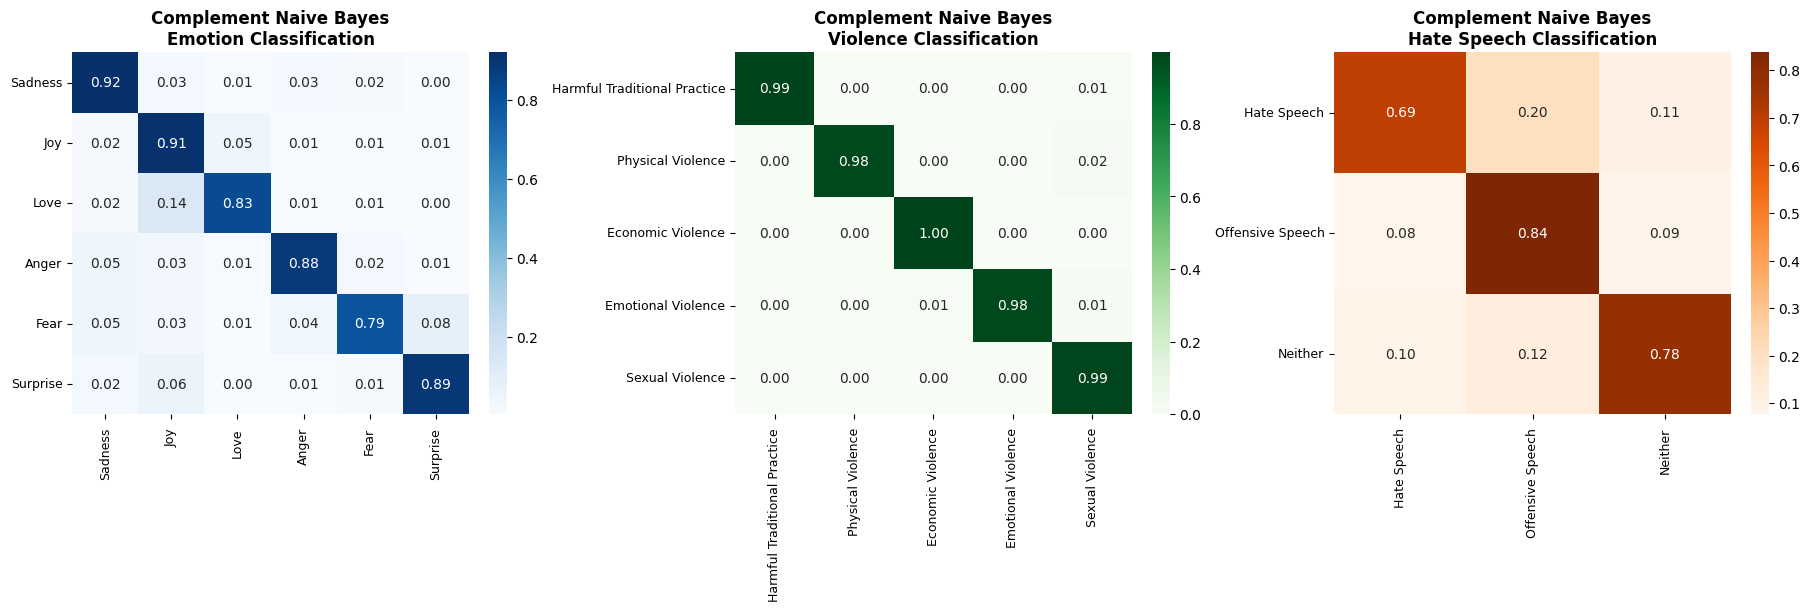

In [49]:
plot_confusion_matrices_subplot(cnb_emotion_pred, cnb_violence_pred, cnb_hate_pred, 'Complement Naive Bayes')

In [50]:
# ============================================================================
# 5. LIGHTGBM
# ============================================================================
print("\n" + "="*80)
print("TRAINING LIGHTGBM CLASSIFIER")
print("="*80)

lgbm_emotion = LGBMClassifier(n_estimators=200, random_state=42, n_jobs=-1, verbose=-1)
lgbm_violence = LGBMClassifier(n_estimators=200, random_state=42, n_jobs=-1, verbose=-1)
lgbm_hate = LGBMClassifier(n_estimators=200, random_state=42, n_jobs=-1, verbose=-1)

print("Training models...")
lgbm_emotion.fit(X_emotion_train, y_emotion_train)
lgbm_violence.fit(X_violence_train, y_violence_train)
lgbm_hate.fit(X_hate_train, y_hate_train)

lgbm_emotion_pred = lgbm_emotion.predict(X_emotion_test)
lgbm_violence_pred = lgbm_violence.predict(X_violence_test)
lgbm_hate_pred = lgbm_hate.predict(X_hate_test)

evaluate_model('LightGBM', lgbm_emotion_pred, lgbm_violence_pred, lgbm_hate_pred)


TRAINING LIGHTGBM CLASSIFIER
Training models...

---------------------------------------------------------------------------
CLASS          ACCURACY       PRECISION      RECALL         F1-SCORE       
---------------------------------------------------------------------------
Emotion        0.8964         0.8683         0.8881         0.8768         
Violence       0.9994         0.9994         0.9996         0.9995         
Hate Speech    0.8963         0.8824         0.8962         0.8886         
---------------------------------------------------------------------------
Overall Avg    0.9307         0.9167         0.9279         0.9216         
---------------------------------------------------------------------------


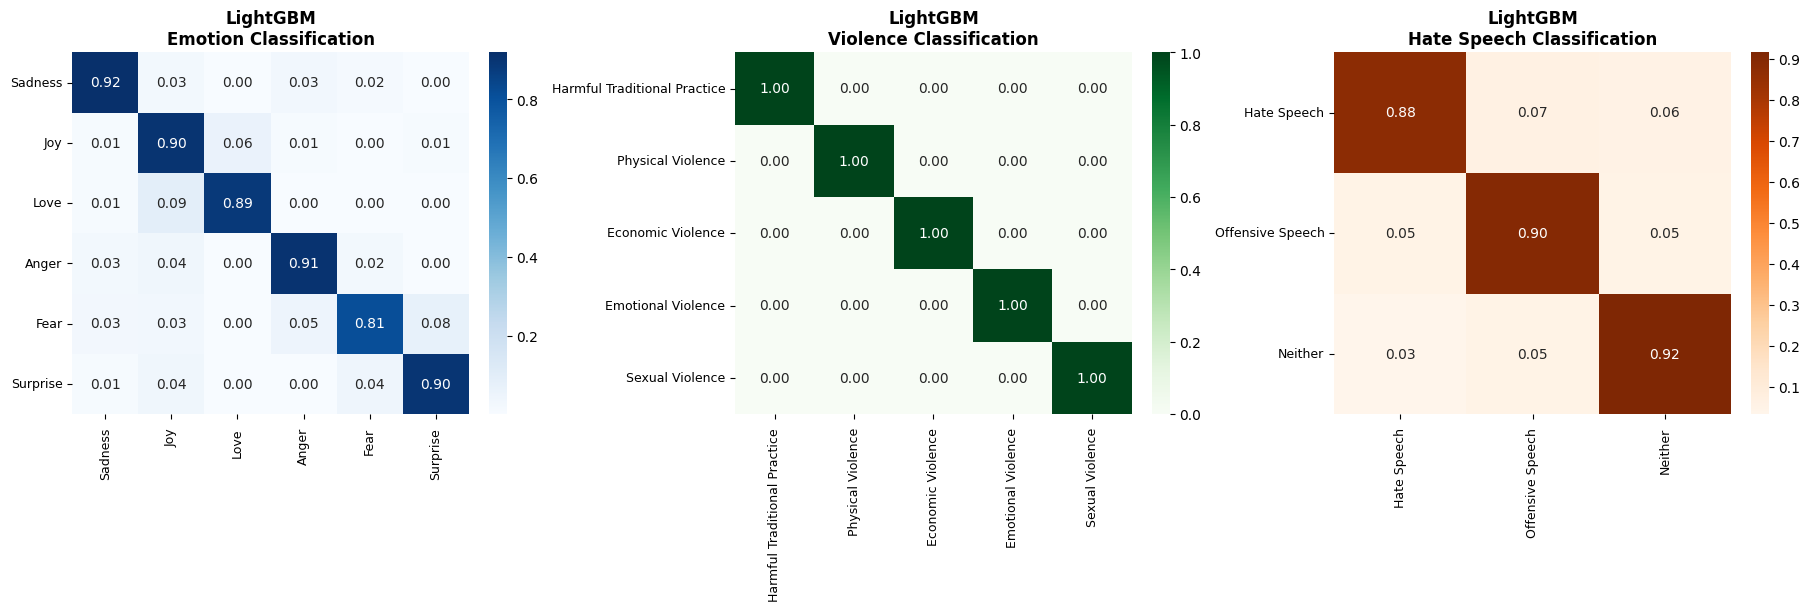

In [51]:
plot_confusion_matrices_subplot(lgbm_emotion_pred, lgbm_violence_pred, lgbm_hate_pred, 'LightGBM')

In [52]:
# ============================================================================
# 6. CATBOOST
# ============================================================================
# Initialize CatBoost models with optimal parameters
catboost_emotion = CatBoostClassifier(iterations=200, depth=8, learning_rate=0.1, loss_function='MultiClass', random_seed=42, verbose=False, thread_count=-1)
catboost_violence = CatBoostClassifier(iterations=200, depth=8, learning_rate=0.1, loss_function='MultiClass', random_seed=42, verbose=False, thread_count=-1)
catboost_hate = CatBoostClassifier(iterations=200, depth=8, learning_rate=0.1, loss_function='MultiClass', random_seed=42, verbose=False, thread_count=-1)

print("Training models...")
catboost_emotion.fit(X_emotion_train, y_emotion_train)
catboost_violence.fit(X_violence_train, y_violence_train)
catboost_hate.fit(X_hate_train, y_hate_train)

catboost_emotion_pred = catboost_emotion.predict(X_emotion_test)
catboost_violence_pred = catboost_violence.predict(X_violence_test)
catboost_hate_pred = catboost_hate.predict(X_hate_test)

evaluate_model('CatBoost', catboost_emotion_pred, catboost_violence_pred, catboost_hate_pred)

Training models...

---------------------------------------------------------------------------
CLASS          ACCURACY       PRECISION      RECALL         F1-SCORE       
---------------------------------------------------------------------------
Emotion        0.8594         0.8802         0.8054         0.8334         
Violence       0.9961         0.9946         0.9972         0.9958         
Hate Speech    0.8020         0.7765         0.7815         0.7692         
---------------------------------------------------------------------------
Overall Avg    0.8858         0.8838         0.8613         0.8662         
---------------------------------------------------------------------------


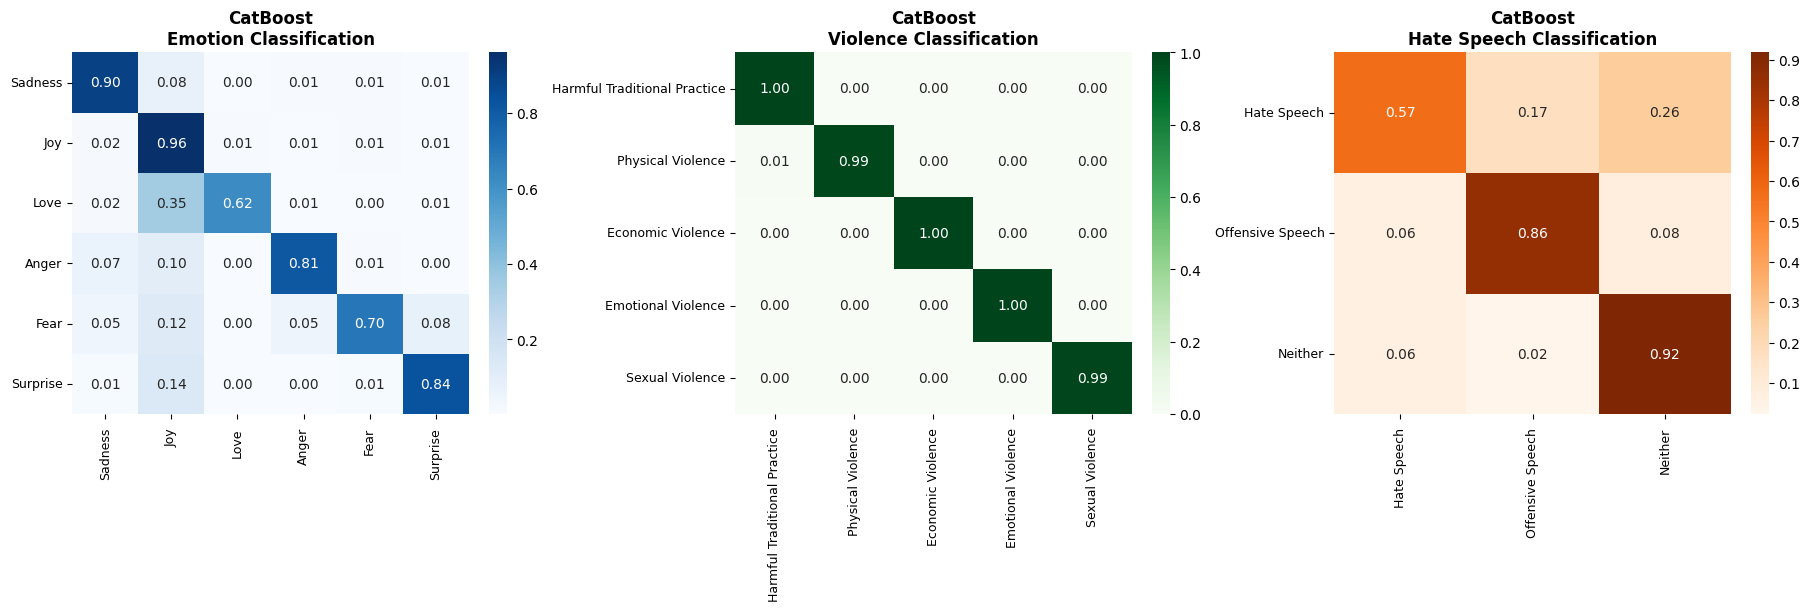

In [53]:
plot_confusion_matrices_subplot(catboost_emotion_pred, catboost_violence_pred, catboost_hate_pred, 'CatBoost')

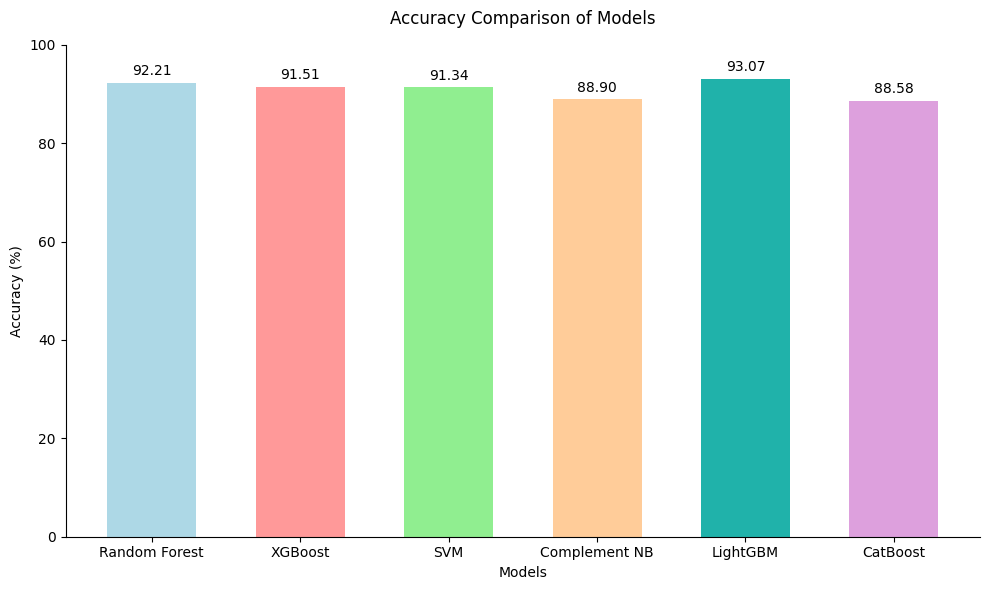

In [13]:
import matplotlib.pyplot as plt
import numpy as np

# Data
models = ['Random Forest','XGBoost','SVM','Complement NB','LightGBM','CatBoost']
acc = [92.21, 91.51, 91.34, 88.90, 93.07, 88.58]

# Pastel colors similar to your reference
colors = [
    '#ADD8E6',  # light blue
    '#FF9999',  # light red
    '#90EE90',  # light green
    '#FFCC99',  # light orange
    '#20B2AA',  # teal
    '#DDA0DD'   # plum
]

plt.figure(figsize=(10, 6))
bars = plt.bar(models, acc, color=colors, width=0.6)

# Labels
plt.ylabel('Accuracy (%)')
plt.xlabel('Models')
plt.title('Accuracy Comparison of Models', pad=15)
# Y-axis range like reference
plt.ylim(0, 100)

# Remove top/right borders for clean look
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# Value labels on top of bars
for bar, value in zip(bars, acc):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f'{value:.2f}',
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.tight_layout()
plt.show()
